In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [90]:
df = pd.read_csv(r"C:\Users\phunk\OneDrive\Desktop\MyProject\data\Microdata LFS Q3 2566_N.csv")

In [91]:
df.head(10)

,REG,CWT,AREA,TYPE,MEMBERS,RELATION,SEX,AGE,MARITAL,LST_MEN,RE_ED,WK
0,1,10,1,1,1,1,2,53,2,1,2,Work
1,1,10,1,1,3,1,1,72,4,0,4,No_Work
2,1,10,1,1,3,3,1,40,1,0,4,Work
3,1,10,1,1,3,3,1,35,1,1,4,Work
4,1,10,1,1,4,1,1,72,2,0,3,No_Work
5,1,10,1,1,4,2,2,66,2,0,6,No_Work
6,1,10,1,1,4,3,1,39,1,0,11,Work
7,1,10,1,1,4,3,1,33,1,1,11,Work
8,1,10,1,1,2,1,1,75,2,0,2,No_Work
9,1,10,1,1,2,2,2,70,2,1,2,No_Work


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 163546 entries, 0 to 163545
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   REG       163546 non-null  int64
 1   CWT       163546 non-null  int64
 2   AREA      163546 non-null  int64
 3   TYPE      163546 non-null  int64
 4   MEMBERS   163546 non-null  int64
 5   RELATION  163546 non-null  int64
 6   SEX       163546 non-null  int64
 7   AGE       163546 non-null  int64
 8   MARITAL   163546 non-null  int64
 9   LST_MEN   163546 non-null  int64
 10  RE_ED     163546 non-null  int64
 11  WK        163546 non-null  str  
dtypes: int64(11), str(1)
memory usage: 15.0 MB


In [93]:
df.describe()

,REG,CWT,AREA,TYPE,MEMBERS,RELATION,SEX,AGE,MARITAL,LST_MEN,RE_ED
count,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000,163546.000000
mean,3.244897,50.143935,1.468718,1.000404,3.170875,2.560466,1.532254,49.369853,2.387175,0.350935,4.726646
std,1.170733,25.110736,0.499022,0.020085,1.540289,2.445233,0.498960,17.988589,1.217311,0.477264,3.305103
min,1.000000,10.000000,1.000000,1.000000,1.000000,0.000000,1.000000,15.000000,1.000000,0.000000,1.000000
25%,2.000000,31.000000,1.000000,1.000000,2.000000,1.000000,1.000000,36.000000,2.000000,0.000000,2.000000
50%,3.000000,48.000000,1.000000,1.000000,3.000000,2.000000,2.000000,51.000000,2.000000,0.000000,4.000000
75%,4.000000,71.000000,2.000000,1.000000,4.000000,3.000000,2.000000,63.000000,3.000000,1.000000,5.000000
max,5.000000,96.000000,2.000000,2.000000,12.000000,15.000000,2.000000,110.000000,6.000000,1.000000,17.000000


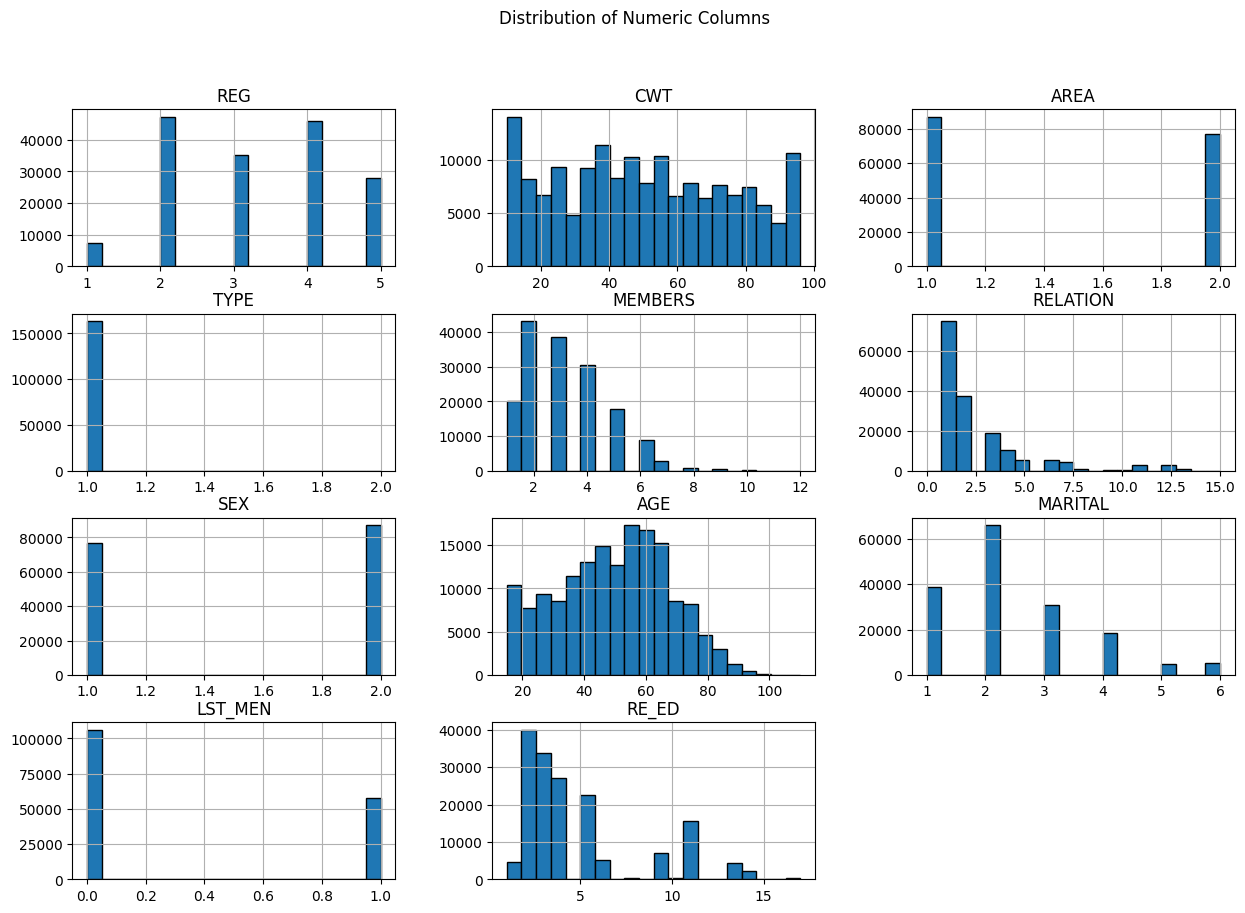

In [94]:
numeric_cols = df.select_dtypes(include=['number']).columns

df[numeric_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numeric Columns')
plt.show()

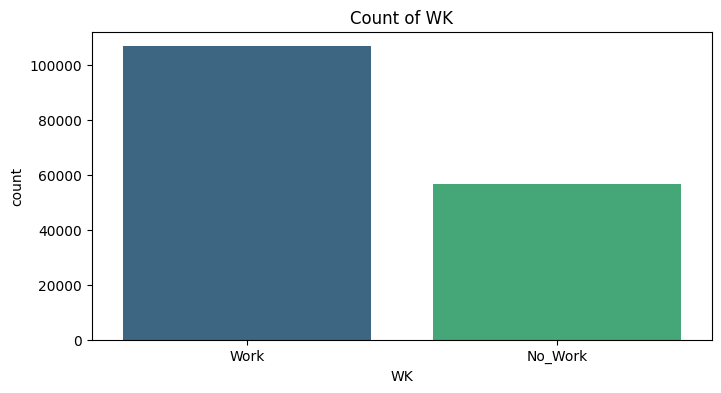

In [95]:
cat_cols = df.select_dtypes(include=['category', 'object', 'string']).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    
    plt.title(f'Count of {col}')
    plt.show()

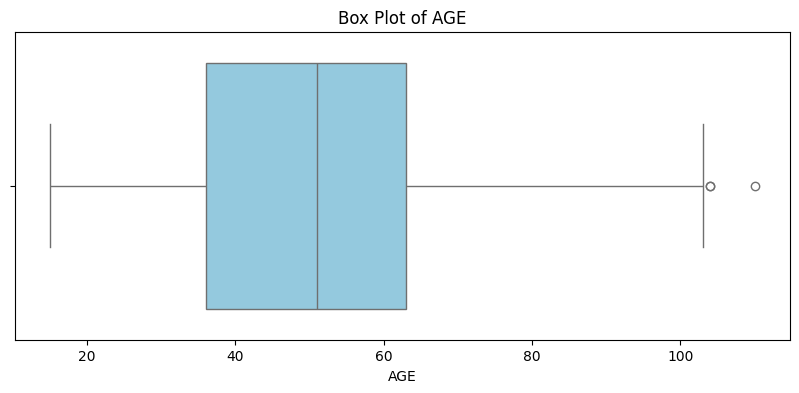

        REG  CWT  AREA  TYPE  MEMBERS  RELATION  SEX  AGE  MARITAL  LST_MEN  \
22687     2   20     1     1        5        12    2  104        4        1   
25581     2   22     1     1        6         7    2  110        4        0   
117515    4   41     1     1        2         7    2  104        4        1   

        RE_ED       WK  
22687       1  No_Work  
25581       2  No_Work  
117515      2  No_Work  


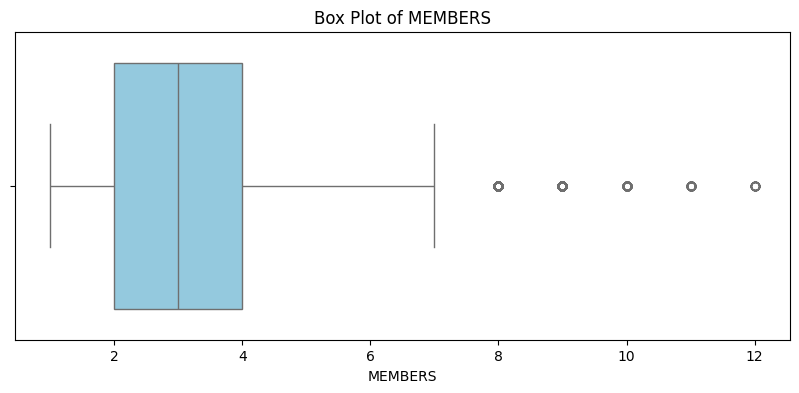

        REG  CWT  AREA  TYPE  MEMBERS  RELATION  SEX  AGE  MARITAL  LST_MEN  \
2141      1   10     1     1        8         1    2   71        2        0   
2142      1   10     1     1        8         2    1   81        2        0   
2143      1   10     1     1        8         3    1   52        1        0   
2144      1   10     1     1        8         4    2   42        6        0   
2145      1   10     1     1        8         6    2   19        1        0   
...     ...  ...   ...   ...      ...       ...  ...  ...      ...      ...   
163507    5   96     2     1        8         2    2   69        2        0   
163508    5   96     2     1        8         3    1   30        1        0   
163509    5   96     2     1        8         4    1   41        4        0   
163510    5   96     2     1        8         4    2   36        2        0   
163511    5   96     2     1        8         5    1   35        2        0   

        RE_ED       WK  
2141        2  No_Work  
2

In [96]:
numeric_cols_outlier = ['AGE','MEMBERS']

for col in numeric_cols_outlier:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outlier)

In [97]:
for col in numeric_cols_outlier:
    df[f"{col}_log"] = np.log1p(df[col])

In [98]:
num_log = ['AGE', 'MEMBERS', 'AGE_log', 'MEMBERS_log']

for col_num_log in num_log:
    group1 = df[df['WK'] == 'Work'][col_num_log]
    group2 = df[df['WK'] == 'No_Work'][col_num_log]

    t_stat, p_value = stats.ttest_ind(group1, group2)
    print(f"p-value = {p_value:.4f}")

p-value = 0.0000
p-value = 0.0134
p-value = 0.0000
p-value = 0.0603


In [ ]:
cat_col = df.columns.drop(['AGE', 'MEMBERS', 'AGE_log', 'MEMBERS_log', 'WK'])

for col in cat_col:
    contingency_table = pd.crosstab(df[col],df['WK'])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"p-value = {p_value:.4f}")

p-value = 0.0000
p-value = 0.0000
p-value = 0.0000
p-value = 0.0000
p-value = 0.0000
p-value = 0.0000
p-value = 0.0000
p-value = 0.0000
p-value = 0.0000


In [113]:
X = df.drop(['WK', 'AGE', 'MEMBERS_log'], axis=1)
y = df['WK']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

--- Classification Report ---
              precision    recall  f1-score   support

     No_Work       0.75      0.66      0.70     11344
        Work       0.83      0.88      0.86     21366

    accuracy                           0.81     32710
   macro avg       0.79      0.77      0.78     32710
weighted avg       0.80      0.81      0.80     32710



<Figure size 800x600 with 0 Axes>

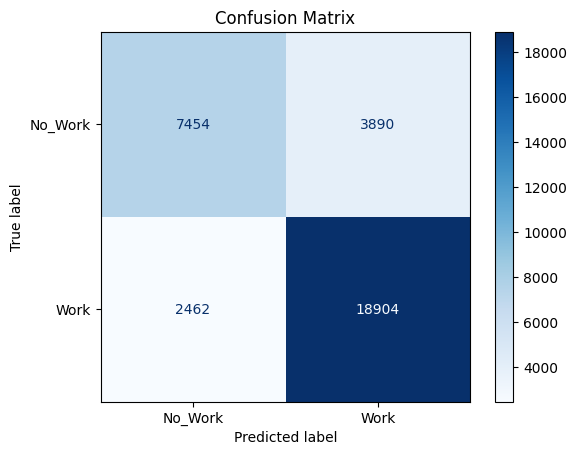

In [114]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()